In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection   import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

### data info

In [4]:
df = pd.read_csv("typhoid.csv")

In [5]:
df.head()

,Patient_ID,Age,Gender,Admission_Type,Ward_Department,Temperature_C,WBC_Count,Widal_Test,Stool_Culture,Bowel_Perforation,Comorbidities_Count,Insurance_Type,Length_of_Stay_Days
0,TYP-00001,53,Female,Emergency,Male Medical,39.7,9.0,Positive (1:160),Positive,0,1,Cash,7.4
1,TYP-00002,16,Male,Emergency,Pediatrics,39.9,13.1,Positive (1:160),Pending,0,0,Cash,5.3
2,TYP-00003,73,Female,Emergency,Female Medical,37.4,7.2,Positive (1:320),Positive,0,1,Cash,6.6
3,TYP-00004,62,Female,Emergency,Male Medical,37.4,7.5,Positive (1:160),Positive,0,0,NHIF,6.0
4,TYP-00005,22,Male,Emergency,ICU,38.8,5.7,Positive (1:320),Positive,0,0,NHIF,2.3


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2500 non-null   str    
 1   Age                  2500 non-null   int64  
 2   Gender               2500 non-null   str    
 3   Admission_Type       2500 non-null   str    
 4   Ward_Department      2500 non-null   str    
 5   Temperature_C        2500 non-null   float64
 6   WBC_Count            2500 non-null   float64
 7   Widal_Test           2500 non-null   str    
 8   Stool_Culture        2500 non-null   str    
 9   Bowel_Perforation    2500 non-null   int64  
 10  Comorbidities_Count  2500 non-null   int64  
 11  Insurance_Type       2500 non-null   str    
 12  Length_of_Stay_Days  2500 non-null   float64
dtypes: float64(3), int64(3), str(7)
memory usage: 405.3 KB


In [7]:
df.describe()

,Age,Temperature_C,WBC_Count,Bowel_Perforation,Comorbidities_Count,Length_of_Stay_Days
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,37.002400,38.788560,11.699280,0.065200,0.770400,6.339800
std,21.071744,0.804761,3.540831,0.246928,0.901337,2.678675
min,2.000000,35.600000,0.700000,0.000000,0.000000,1.200000
25%,19.000000,38.200000,9.200000,0.000000,0.000000,4.600000
50%,36.000000,38.800000,11.700000,0.000000,1.000000,5.900000
75%,55.000000,39.300000,14.100000,0.000000,1.000000,7.400000
max,74.000000,41.300000,22.800000,1.000000,3.000000,18.300000


In [8]:
df.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
Admission_Type         0
Ward_Department        0
Temperature_C          0
WBC_Count              0
Widal_Test             0
Stool_Culture          0
Bowel_Perforation      0
Comorbidities_Count    0
Insurance_Type         0
Length_of_Stay_Days    0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2500, dtype: bool

### data visulazation


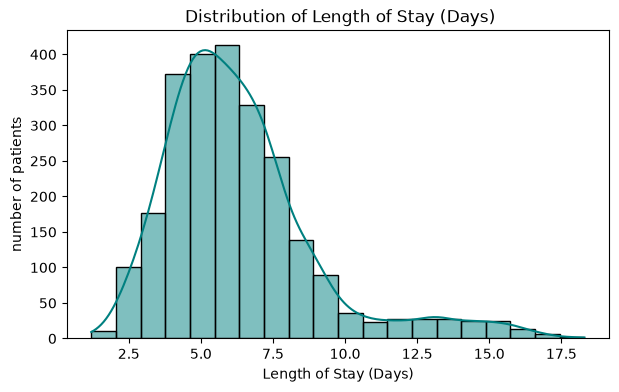

In [10]:
plt.figure(figsize=(7,4))
sns.histplot(df["Length_of_Stay_Days"], bins=20, kde=True, color="teal")
plt.title(" Distribution of Length of Stay (Days)")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("number of patients")
plt.show()


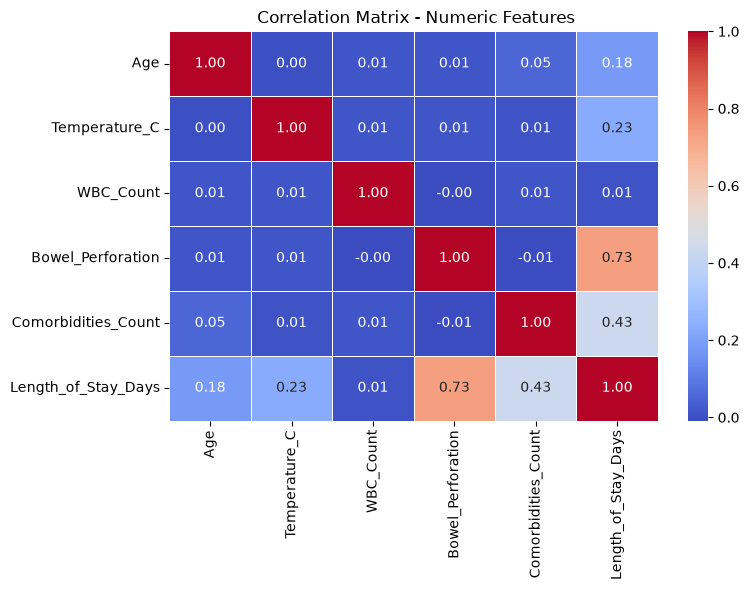

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [11]:
plt.figure(figsize=(8,6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title(" Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))


C:\Users\THEA AUDAX ZILIMU\AppData\Local\Temp\ipykernel_17600\4218911847.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


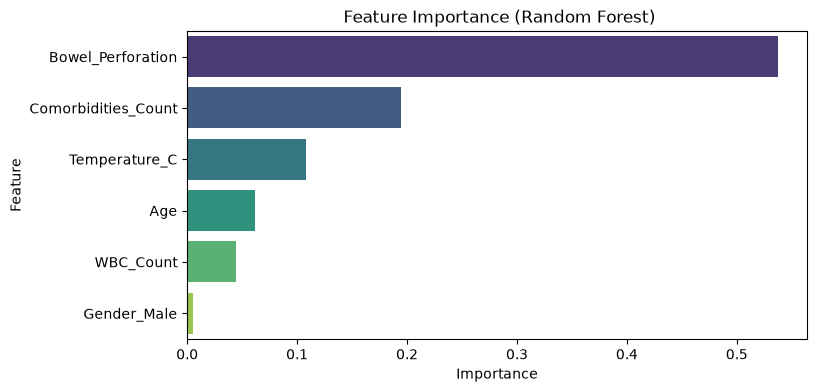

In [12]:
X = df.drop(columns=["Patient_ID", "Length_of_Stay_Days"])
y = df["Length_of_Stay_Days"]
X_encoded = pd.get_dummies(X, drop_first=True)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_encoded, y)

importance_df = pd.DataFrame(
    {"Feature": X_encoded.columns, "Importance": rf.feature_importances_}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    x="Importance", y="Feature", data=importance_df.head(6), palette="viridis"
)
plt.title(" Feature Importance (Random Forest)")
plt.show()

C:\Users\THEA AUDAX ZILIMU\AppData\Local\Temp\ipykernel_17600\2131356416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


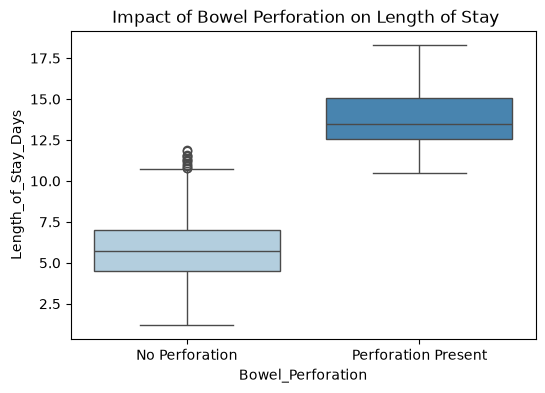

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    x="Bowel_Perforation", y="Length_of_Stay_Days", data=df, palette="Blues"
)
plt.xticks([0, 1], ["No Perforation", "Perforation Present"])
plt.title(" Impact of Bowel Perforation on Length of Stay")
plt.show()

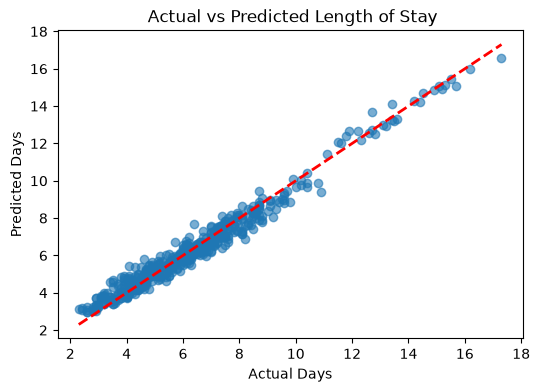

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
y_pred = rf.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2
)
plt.xlabel("Actual Days")
plt.ylabel("Predicted Days")
plt.title(" Actual vs Predicted Length of Stay")
plt.show()

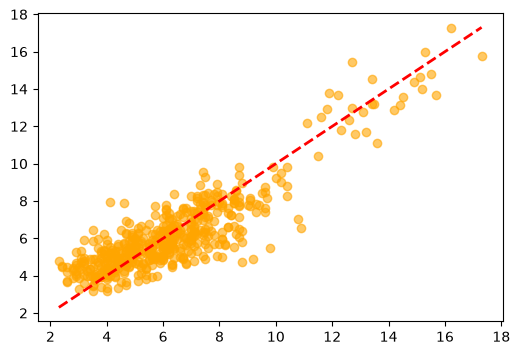

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
plt.figure(figsize=(6, 4))
plt.scatter(y_test, lr_pred, alpha=0.6, color="orange")
plt.plot(
[y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2
)


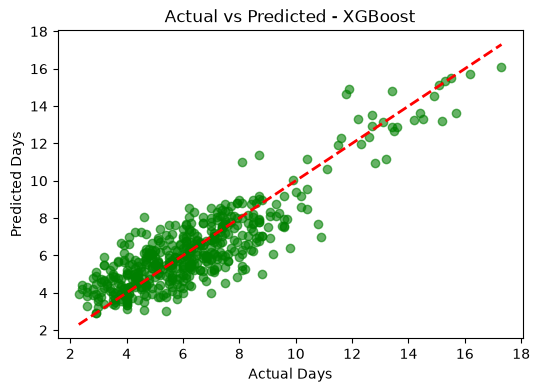

In [16]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, xgb_pred, alpha=0.6, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Days")
plt.ylabel("Predicted Days")
plt.title("Actual vs Predicted - XGBoost")
plt.show()



In [17]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 3)}

results = pd.DataFrame([
    get_metrics(y_test, lr_pred, "Linear Regression"),
    get_metrics(y_test, rf_pred, "Random Forest"),
    get_metrics(y_test, xgb_pred, "XGBoost")
])

print(results)

               Model   MAE  RMSE     R2
0  Linear Regression  0.94  1.20  0.773
1      Random Forest  0.92  1.16  0.789
2            XGBoost  0.97  1.23  0.762


In [18]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("MAE - Training :", round(mean_absolute_error(y_train, train_pred), 2))
print("MAE - Test :", round(mean_absolute_error(y_test, test_pred), 2))

MAE - Training : 0.35
MAE - Test : 0.92


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("the best part is")
print(grid_search.best_params_)

the best part is
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [20]:
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print("MAE - Tuned Model:", mean_absolute_error(y_test, best_rf_pred))
print("RMSE - Tuned Model:", mean_squared_error(y_test, best_rf_pred) ** 0.5)
print("R2 - Tuned Model:", r2_score(y_test, best_rf_pred))

MAE - Tuned Model: 0.9038391053952186
RMSE - Tuned Model: 1.1414530703116506
R2 - Tuned Model: 0.7951660271755933


In [21]:
print("before ")
print("MAE:", 0.92, "RMSE:", 1.16, "R2:", 0.789)

print("\n after ")
print("MAE:", mean_absolute_error(y_test, best_rf_pred))
print("RMSE:", mean_squared_error(y_test, best_rf_pred) ** 0.5)
print("R2:", r2_score(y_test, best_rf_pred))

before 
MAE: 0.92 RMSE: 1.16 R2: 0.789

 after 
MAE: 0.9038391053952186
RMSE: 1.1414530703116506
R2: 0.7951660271755933


In [22]:
train_pred_tuned = best_rf.predict(X_train)
test_pred_tuned = best_rf.predict(X_test)

print("MAE - Training (Tuned):",round( mean_absolute_error(y_train, train_pred_tuned),1))
print("MAE - Test (Tuned):",round( mean_absolute_error(y_test, test_pred_tuned),2))

MAE - Training (Tuned): 0.7
MAE - Test (Tuned): 0.9


In [23]:
import joblib

joblib.dump(rf, "random_forest_los_model.pkl")
joblib.dump(X_encoded.columns.tolist(), "model_columns.pkl")

print("Model was complete successiful!")

Model was complete successiful!
